### Tipos de variables 

#### 1. Cargar librerias y base de datos

In [108]:
# pip import matplotlib
import pandas as pd #Abre las bases de datos
import numpy as np  #Para operaciones númericas
import matplotlib.pyplot as plt #Para graficar

In [109]:
data=pd.read_csv("BankChurners.csv") #Cargamos la base de datos
data.head() # Mostramos las primeras filas de la base de datos

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


#### 2. Información de la base y las variables

In [110]:
data.info() #Información sobre los tipos de variables y valores nulos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

In [111]:
#Eliminar las variables 21 y 22
data.drop(columns=data.columns[[21,22]],axis=1,inplace=True)
data.info() #Verificamos que se eliminaron las columnas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

#### 3. Tipos de variables 
- int64 -> número entero
- float64 -> número continuo (con decimales)
- object

#### 4. Acotamos las bases de datos

In [112]:
# Seleccionar columnas 2 a 8 y a la 13
data_subset = data.iloc[:,list(range(2,8))+[13]]

#Verificar resultados
data_subset.head()

,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Credit_Limit
0,45,M,3,High School,Married,$60K - $80K,12691.0
1,49,F,5,Graduate,Single,Less than $40K,8256.0
2,51,M,3,Graduate,Married,$80K - $120K,3418.0
3,40,F,4,High School,Unknown,Less than $40K,3313.0
4,40,M,3,Uneducated,Married,$60K - $80K,4716.0


In [113]:
data_subset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer_Age     10127 non-null  int64  
 1   Gender           10127 non-null  object 
 2   Dependent_count  10127 non-null  int64  
 3   Education_Level  10127 non-null  object 
 4   Marital_Status   10127 non-null  object 
 5   Income_Category  10127 non-null  object 
 6   Credit_Limit     10127 non-null  float64
dtypes: float64(1), int64(2), object(4)
memory usage: 553.9+ KB


#### 5. Variables númericas

##### Opción 1 : Estandarización (StandardScaler)
La más usada en modelos estadísticos y machine learning
- Transforma la variable a media 0 y desviación y estándar 1
- StandardScaler -> regresión, PCA, K-Means, redes neuronales

In [114]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
data_subset['Credit_Limit_scaled']=scaler.fit_transform(data_subset[['Credit_Limit' ]])

data_subset[['Credit_Limit', 'Credit_Limit_scaled']].head()

/tmp/ipykernel_15172/108310719.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_subset['Credit_Limit_scaled']=scaler.fit_transform(data_subset[['Credit_Limit' ]])


,Credit_Limit,Credit_Limit_scaled
0,12691.0,0.446622
1,8256.0,-0.041367
2,3418.0,-0.573698
3,3313.0,-0.585251
4,4716.0,-0.430877


##### Opción 2. Escalamiento Min-Max
Útil cuando quieres valores entre 0 y 1
- MinMaxScaler -> algoritmos basados en distancia o límites

In [115]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
data_subset['Credit_Limit_scaled2']=scaler.fit_transform(data_subset[['Credit_Limit' ]])
data_subset[['Credit_Limit', 'Credit_Limit_scaled2']].head()

/tmp/ipykernel_15172/2826853028.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_subset['Credit_Limit_scaled2']=scaler.fit_transform(data_subset[['Credit_Limit' ]])


,Credit_Limit,Credit_Limit_scaled2
0,12691.0,0.340190
1,8256.0,0.206112
2,3418.0,0.059850
3,3313.0,0.056676
4,4716.0,0.099091


In [116]:
data_subset.head()

,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Credit_Limit,Credit_Limit_scaled,Credit_Limit_scaled2
0,45,M,3,High School,Married,$60K - $80K,12691.0,0.446622,0.340190
1,49,F,5,Graduate,Single,Less than $40K,8256.0,-0.041367,0.206112
2,51,M,3,Graduate,Married,$80K - $120K,3418.0,-0.573698,0.059850
3,40,F,4,High School,Unknown,Less than $40K,3313.0,-0.585251,0.056676
4,40,M,3,Uneducated,Married,$60K - $80K,4716.0,-0.430877,0.099091


##### Opción 3. Escalamiento manual (Formula explícita)

- Manual -> explicación conceptual del escalamiento

In [117]:
mean=data_subset['Credit_Limit'].mean()
std=data_subset['Credit_Limit'].std()

data_subset['Credit_Limit_scaled3']=(data_subset['Credit_Limit']-mean)/std
data_subset[['Credit_Limit', 'Credit_Limit_scaled3']].head()

/tmp/ipykernel_15172/471108674.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_subset['Credit_Limit_scaled3']=(data_subset['Credit_Limit']-mean)/std


,Credit_Limit,Credit_Limit_scaled3
0,12691.0,0.446600
1,8256.0,-0.041365
2,3418.0,-0.573669
3,3313.0,-0.585222
4,4716.0,-0.430856


#### 6. Visualización de antes y después del escalamiento

In [118]:
# Resumen estadístico antes del escalamiento
data_subset['Credit_Limit'].describe().round(2)


count    10127.00
mean      8631.95
std       9088.78
min       1438.30
25%       2555.00
50%       4549.00
75%      11067.50
max      34516.00
Name: Credit_Limit, dtype: float64

In [119]:
# Resumen estadístico después del escalamiento
data_subset['Credit_Limit_scaled'].describe().round(2)


count    10127.00
mean         0.00
std          1.00
min         -0.79
25%         -0.67
50%         -0.45
75%          0.27
max          2.85
Name: Credit_Limit_scaled, dtype: float64

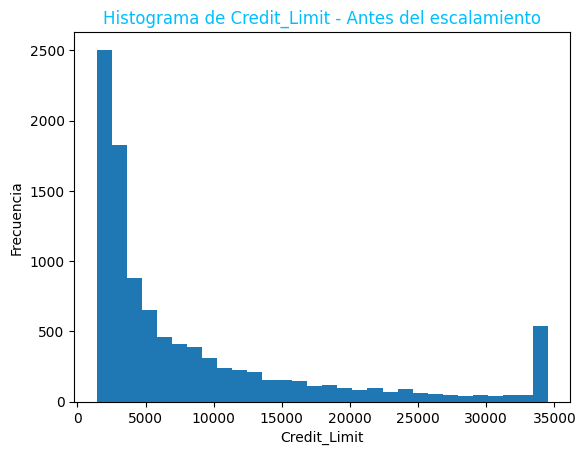

In [120]:
# Histograma antes
import matplotlib.pyplot as plt
plt.figure()
plt.hist(data_subset['Credit_Limit'], bins=30)
plt.title('Histograma de Credit_Limit - Antes del escalamiento', color="deepskyblue")
plt.xlabel('Credit_Limit')
plt.ylabel('Frecuencia')
plt.show()

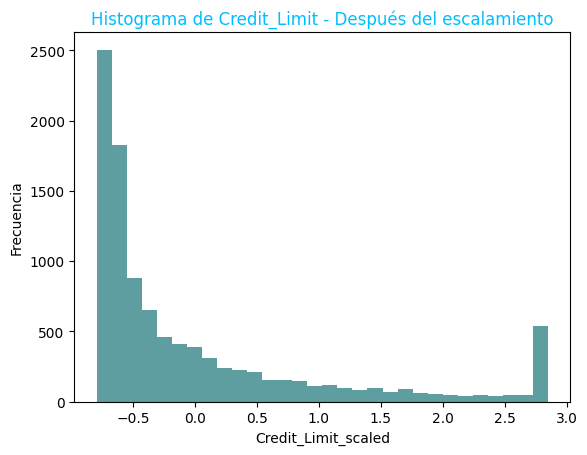

In [121]:
# Histograma después
plt.figure()
plt.hist(data_subset['Credit_Limit_scaled'], bins=30, color='cadetblue')
plt.title('Histograma de Credit_Limit - Después del escalamiento', color="deepskyblue")
plt.xlabel('Credit_Limit_scaled')
plt.ylabel('Frecuencia')
plt.show()  

#### 7. Variable categorica: nominal (One-hot y agrupamiento)


In [122]:
# One-hot encoding sin eliminar categorías 
gender_dummies=pd.get_dummies(data_subset['Gender'])

# (opcional) renmobrar columnas para claridad
gender_dummies.columns=['Female','Male']

# Agregar al DataFrame original 
data_subset=pd.concat([data_subset,gender_dummies],axis=1)

# (opcional) eliminar la variable original 
#data_subset.drop('Gender',axis=1,inplace=True)

data_subset[['Gender','Female','Male']].head()

,Gender,Female,Male
0,M,False,True
1,F,True,False
2,M,False,True
3,F,True,False
4,M,False,True


In [123]:
data_subset[['Gender','Female','Male']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Gender  10127 non-null  object
 1   Female  10127 non-null  bool  
 2   Male    10127 non-null  bool  
dtypes: bool(2), object(1)
memory usage: 99.0+ KB


In [124]:
data_subset['Female']=data_subset['Female'].astype(int)
data_subset['Male']=data_subset['Male'].astype(int)
data_subset[['Female','Male']].dtypes

Female    int64
Male      int64
dtype: object

##### Nota Importante
- En modeloes lineales, usar ambas dummies puede generar multicolinealidad
- En árboles, Random Forest o XGBoost, no es un problema 

#### 7.1 Marital_Status agrupamiento


In [125]:
# Frecuencias originales
data_subset['Marital_Status'].value_counts()

Marital_Status
Married     4687
Single      3943
Unknown      749
Divorced     748
Name: count, dtype: int64

In [126]:
# Diccionario de agrupación
marital_map = {
    'Single': 'Single',
    'Married': 'Married',
    'Divorced': 'Other',
    'Unknown': 'Other'
}

data_subset['Marital_Status_grouped'] = (
    data_subset['Marital_Status']
    .map(marital_map)
    .fillna('Other'))

In [127]:
# Frecuencias después de agrupar
data_subset['Marital_Status_grouped'].value_counts()

Marital_Status_grouped
Married    4687
Single     3943
Other      1497
Name: count, dtype: int64

#### 8. Variable categorica : Ordinal (Label encoding)

In [128]:
from sklearn.preprocessing import LabelEncoder

# Inicializar el codificador 
le=LabelEncoder()

# Label encoding para Marital_Status
data_subset['Marital_Status_encoded']=le.fit_transform(
    data_subset['Marital_Status']
)
# Ver correspondencia cateogía -> número
encoding_map=dict(zip(le.classes_,le.transform(le.classes_)))

encoding_map

{'Divorced': np.int64(0),
 'Married': np.int64(1),
 'Single': np.int64(2),
 'Unknown': np.int64(3)}

In [129]:
data_subset[['Marital_Status','Marital_Status_encoded']].head()

,Marital_Status,Marital_Status_encoded
0,Married,1
1,Single,2
2,Married,1
3,Unknown,3
4,Married,1


In [130]:
# ver categorías únicas en Education_Level
print("Categorías en Education_Level:")
print(data_subset['Education_Level'].unique())

Categorías en Education_Level:
['High School' 'Graduate' 'Uneducated' 'Unknown' 'College' 'Post-Graduate'
 'Doctorate']


In [131]:
print("Categorías en Income_Category:")
print(data_subset['Income_Category'].unique())

Categorías en Income_Category:
['$60K - $80K' 'Less than $40K' '$80K - $120K' '$40K - $60K' '$120K +'
 'Unknown']


In [132]:
education_order=[    'Unknown',
    'Uneducated',
    'High School',
    'College',
    'Graduate',
    'Post-Graduate',
    'Doctorate'
]

income_order=[
    'Unknown',
    'Less than $40K',
    '$40K - $60K',
    '$60K - $80K',
    '$80K - $120K',
    '$120K +'
]

from sklearn.preprocessing import OrdinalEncoder  
encoder=OrdinalEncoder(categories=[education_order,income_order])
data_subset[['Education_Level_ord','Income_Category_ord']]=encoder.fit_transform(
    data_subset[['Education_Level','Income_Category']]
)



In [133]:
# Verl el resultado 

data_subset[['Education_Level','Education_Level_ord','Income_Category','Income_Category_ord']].head(10)   

,Education_Level,Education_Level_ord,Income_Category,Income_Category_ord
0,High School,2.0,$60K - $80K,3.0
1,Graduate,4.0,Less than $40K,1.0
2,Graduate,4.0,$80K - $120K,4.0
3,High School,2.0,Less than $40K,1.0
4,Uneducated,1.0,$60K - $80K,3.0
5,Graduate,4.0,$40K - $60K,2.0
6,Unknown,0.0,$120K +,5.0
7,High School,2.0,$60K - $80K,3.0
8,Uneducated,1.0,$60K - $80K,3.0
9,Graduate,4.0,$80K - $120K,4.0


In [134]:
# Tabla de frecuencias de Education_Level_ord
data_subset['Education_Level'].value_counts()

Education_Level
Graduate         3128
High School      2013
Unknown          1519
Uneducated       1487
College          1013
Post-Graduate     516
Doctorate         451
Name: count, dtype: int64

In [135]:
# Tabla de frecuencias de Education_Level
data_subset['Education_Level'].value_counts(normalize=True).round(2)

Education_Level
Graduate         0.31
High School      0.20
Unknown          0.15
Uneducated       0.15
College          0.10
Post-Graduate    0.05
Doctorate        0.04
Name: proportion, dtype: float64

In [136]:
# Tabla de frecuencias acumuladas de Education_Level
data_subset['Education_Level'].value_counts().sort_values().cumsum()

Education_Level
Doctorate          451
Post-Graduate      967
College           1980
Uneducated        3467
Unknown           4986
High School       6999
Graduate         10127
Name: count, dtype: int64

In [137]:
# Tabla cruzada entre Education_Level & Income_Category
pd.crosstab(
    data_subset['Education_Level'],
    data_subset['Income_Category'],
    margins=True  
)


Income_Category,$120K +,$40K - $60K,$60K - $80K,$80K - $120K,Less than $40K,Unknown,All
Education_Level,,,,,,,
College,70,183,132,175,345,108,1013
Doctorate,37,70,59,57,158,70,451
Graduate,204,553,422,478,1139,332,3128
High School,147,355,307,308,671,225,2013
Post-Graduate,30,111,77,81,170,47,516
Uneducated,119,249,195,217,522,185,1487
Unknown,120,269,210,219,556,145,1519
All,727,1790,1402,1535,3561,1112,10127


In [138]:
pd.crosstab(
    data_subset['Income_Category'],
    data_subset['Education_Level'],
    margins=True  
)

Education_Level,College,Doctorate,Graduate,High School,Post-Graduate,Uneducated,Unknown,All
Income_Category,,,,,,,,
$120K +,70,37,204,147,30,119,120,727
$40K - $60K,183,70,553,355,111,249,269,1790
$60K - $80K,132,59,422,307,77,195,210,1402
$80K - $120K,175,57,478,308,81,217,219,1535
Less than $40K,345,158,1139,671,170,522,556,3561
Unknown,108,70,332,225,47,185,145,1112
All,1013,451,3128,2013,516,1487,1519,10127


In [140]:
pd.crosstab(
    data_subset['Income_Category'],
    data_subset['Education_Level'],
    normalize='index',
).round(4)*100

Education_Level,College,Doctorate,Graduate,High School,Post-Graduate,Uneducated,Unknown
Income_Category,,,,,,,
$120K +,9.63,5.09,28.06,20.22,4.13,16.37,16.51
$40K - $60K,10.22,3.91,30.89,19.83,6.20,13.91,15.03
$60K - $80K,9.42,4.21,30.10,21.90,5.49,13.91,14.98
$80K - $120K,11.40,3.71,31.14,20.07,5.28,14.14,14.27
Less than $40K,9.69,4.44,31.99,18.84,4.77,14.66,15.61
Unknown,9.71,6.29,29.86,20.23,4.23,16.64,13.04


In [141]:
pd.crosstab(
    data_subset['Income_Category'],
    data_subset['Education_Level'],
    normalize='columns',
).round(4)*100

Education_Level,College,Doctorate,Graduate,High School,Post-Graduate,Uneducated,Unknown
Income_Category,,,,,,,
$120K +,6.91,8.20,6.52,7.30,5.81,8.00,7.90
$40K - $60K,18.07,15.52,17.68,17.64,21.51,16.75,17.71
$60K - $80K,13.03,13.08,13.49,15.25,14.92,13.11,13.82
$80K - $120K,17.28,12.64,15.28,15.30,15.70,14.59,14.42
Less than $40K,34.06,35.03,36.41,33.33,32.95,35.10,36.60
Unknown,10.66,15.52,10.61,11.18,9.11,12.44,9.55


In [142]:
pd.crosstab(
    data_subset['Education_Level'],
    data_subset['Marital_Status'],
    normalize='index',
).round(4)*100

Marital_Status,Divorced,Married,Single,Unknown
Education_Level,,,,
College,8.49,46.10,38.10,7.31
Doctorate,7.98,45.45,40.35,6.21
Graduate,7.19,47.28,38.27,7.26
High School,6.36,47.14,38.85,7.65
Post-Graduate,7.95,47.09,36.63,8.33
Uneducated,9.15,44.12,39.41,7.33
Unknown,6.32,45.29,40.88,7.50


In [143]:
pd.crosstab(
    data_subset['Education_Level'],
    data_subset['Marital_Status'],
    normalize='columns',
).round(4)*100

Marital_Status,Divorced,Married,Single,Unknown
Education_Level,,,,
College,11.50,9.96,9.79,9.88
Doctorate,4.81,4.37,4.62,3.74
Graduate,30.08,31.56,30.36,30.31
High School,17.11,20.25,19.83,20.56
Post-Graduate,5.48,5.18,4.79,5.74
Uneducated,18.18,14.00,14.86,14.55
Unknown,12.83,14.68,15.75,15.22
